# Automated Resume Screening and ATS Compatibility Evaluation System Using OpenCV

## 1. Import Libraries

## 2. Read Resume

## 3. OpenCV Preprocessing

## 4. OCR Text Extraction

## 5. Section Detection

## 6. ATS Scoring

## 7. Job Matching

## 8. Resume Suggestions

## 9. Final Report

In [3]:
!pip install opencv-python
!pip install pytesseract
!pip install pymupdf
!pip install pillow
!pip install matplotlib
!pip install pandas
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.2 MB 2.9 MB/s eta 0:00:07
   --- ------------------------------------ 1.6/19.2 MB 3.3 MB/s eta 0:00:06
   ---- ----------------------------------- 2.4/19.2 MB 3.4 MB/s eta 0:00:06
   ------ --------------------------------- 3.1/19.2 MB 3.4 MB/s eta 0:00:05
   -------- ------------------------------- 3.9/19.2 MB 3.5 MB/s eta 0:00:05
   --------- ------------------------------ 4.7/19.2 MB 3.4 MB/s eta 0:00:05
   ----------- ---------------------------- 5.8/19.2 MB 3.5 MB/s eta 0:00:04
   ------------- -------------------------- 6.6/19.2 MB 3.5 MB/s eta 0:00:04
   --------------- ------------------------ 7.3/19.2 MB 3.6 MB/s eta 0:00:04
   ---------------- ----------------------- 8.1/19.2 MB 3.6 MB/s eta 0:00:04
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sys
print(sys.executable)

C:\Users\HANUMAN NARAYANA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


# ==========================
# MODULE 1 : Resume Upload
# ==========================

In [1]:
import os

In [4]:
# Folder containing resumes
resume_folder = "resumes"

# Get all PDF files
pdf_files = []

for file in os.listdir(resume_folder):
    if file.endswith(".pdf"):
        pdf_files.append(file)

print("=" * 60)
print("AVAILABLE RESUMES")
print("=" * 60)

for i, file in enumerate(pdf_files, start=1):
    print(f"{i}. {file}")

AVAILABLE RESUMES
1. Addenki Ruthvik - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
2. Akula Akhil Kumar - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
3. Aluri Veda Varshitha - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf
4. Aniket Prasad - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf
5. Avarla Tharuni Sri - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf
6. Bachu Abhinaya - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
7. Bantu Nandini - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
8. Barla Smaran - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf
9. Battini Sadwik - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf
10. Bendi Sai Kushwanth - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
11. Bijjala Venkatesh - Batch 2028 - B.Tech. - Computer Science & Engineering.pdf
12. Bingi Vaishnavi - Batch 2028 -

In [5]:
# Select resume using its number
choice = int(input("\nEnter Resume Number: "))

resume_name = pdf_files[choice - 1]

# Create complete path
resume_path = os.path.join(resume_folder, resume_name)

print("\nSelected Resume:")
print(resume_name)

print("\nResume Path:")
print(resume_path)

# Check if resume exists
if os.path.exists(resume_path):
    print("\nResume loaded successfully.")
else:
    print("\nResume not found.")


Enter Resume Number:  37



Selected Resume:
Kotha Abhi Sathwik - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf

Resume Path:
resumes\Kotha Abhi Sathwik - Batch 2028 - B.Tech. - Artificial Intelligence and Machine Learning.pdf

Resume loaded successfully.


# MODULE 2: PDF to Image Conversion

## Objective
Convert the uploaded resume PDF into an image for OpenCV processing.

In [10]:
import fitz
import os

# Folder to save image
image_folder = "images"

# Create folder if it doesn't exist
os.makedirs(image_folder, exist_ok=True)

# Output image path
image_path = os.path.join(image_folder, "current_resume.png")

Resume converted successfully.
Saved at: images/current_resume.png


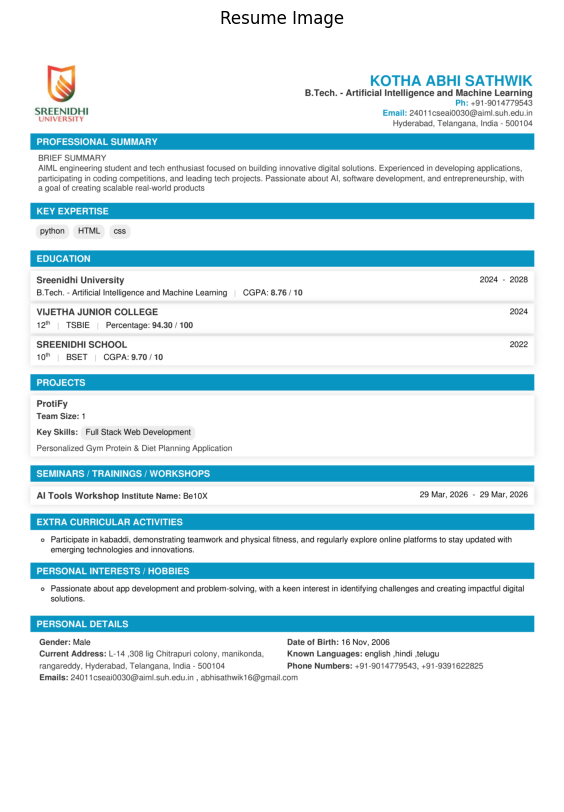

In [12]:
# Open selected resume
doc = fitz.open(resume_path)

# Read first page
page = doc.load_page(0)

# Increase image quality
matrix = fitz.Matrix(3, 3)

# Convert page to image
pix = page.get_pixmap(matrix=matrix)

# Save image
image_path = "images/current_resume.png"
pix.save(image_path)

# Close PDF
doc.close()

print("Resume converted successfully.")
print("Saved at:", image_path)

# Display image
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,10))
plt.imshow(img)
plt.title("Resume Image")
plt.axis("off")
plt.show()

# MODULE 3: OpenCV Image Preprocessing

## Objective
Prepare the resume image for OCR by converting it to grayscale, reducing noise, and enhancing text clarity.

In [13]:
import cv2
import matplotlib.pyplot as plt

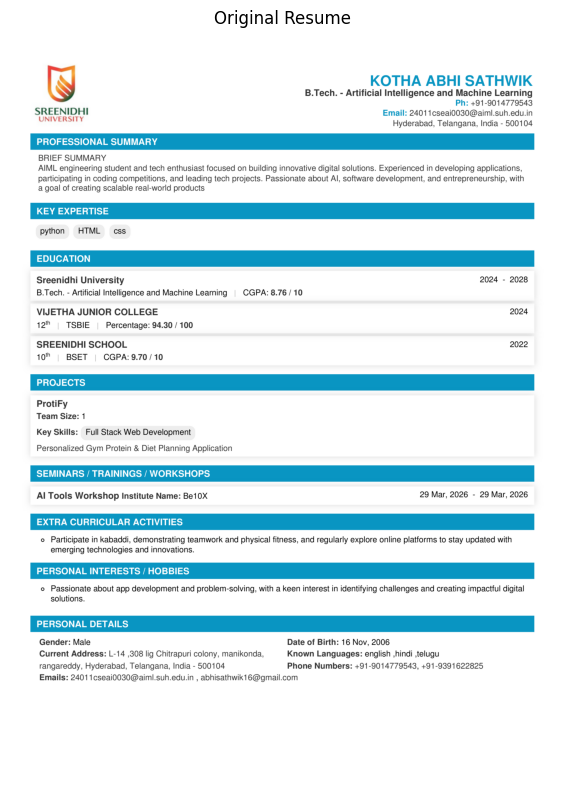

In [14]:
# Read image created in Module 2
image = cv2.imread("images/current_resume.png")

# Convert BGR to RGB for display
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,10))
plt.imshow(rgb)
plt.title("Original Resume")
plt.axis("off")
plt.show()

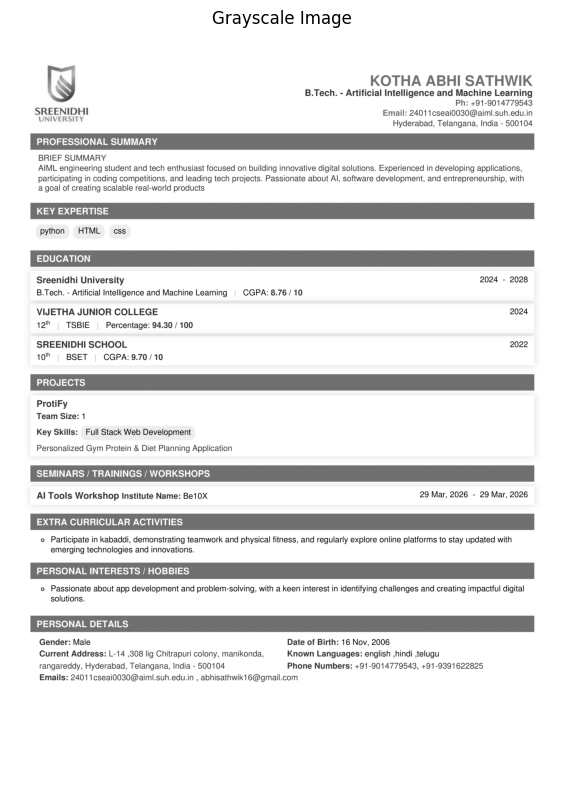

In [15]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,10))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

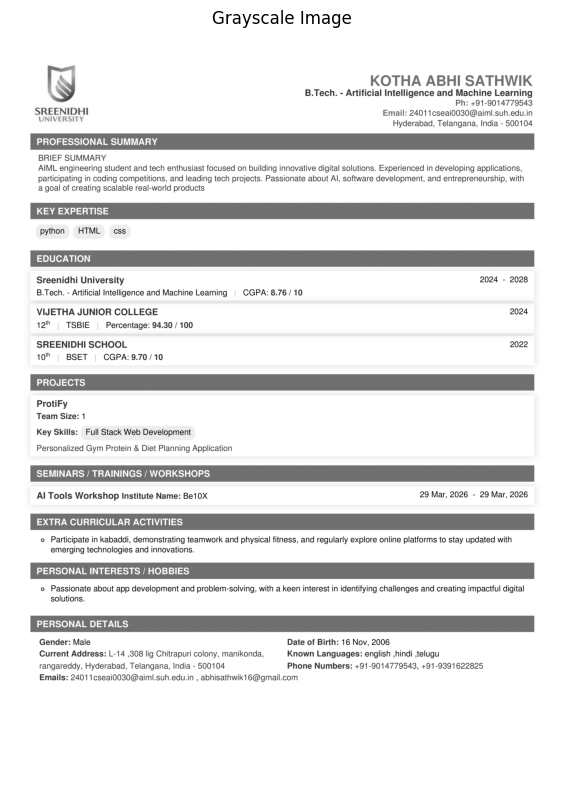

In [16]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,10))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

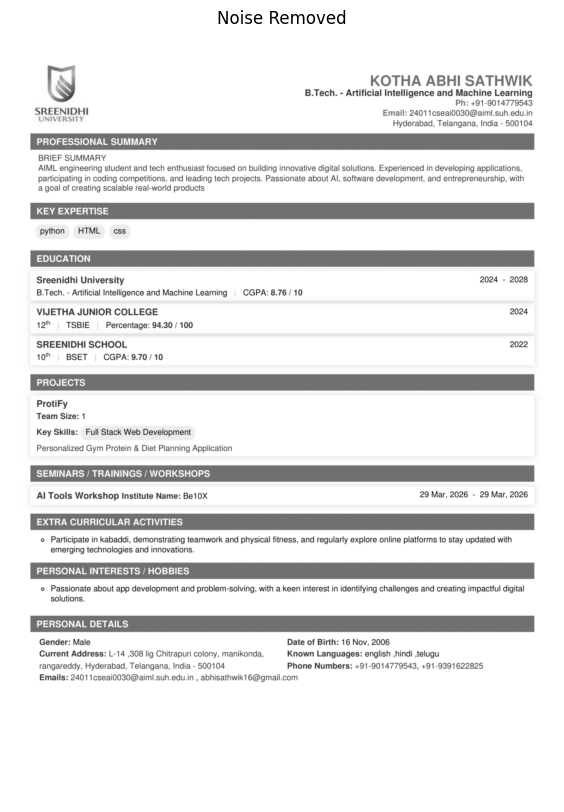

In [17]:
blur = cv2.GaussianBlur(gray, (3,3), 0)

plt.figure(figsize=(8,10))
plt.imshow(blur, cmap="gray")
plt.title("Noise Removed")
plt.axis("off")
plt.show()

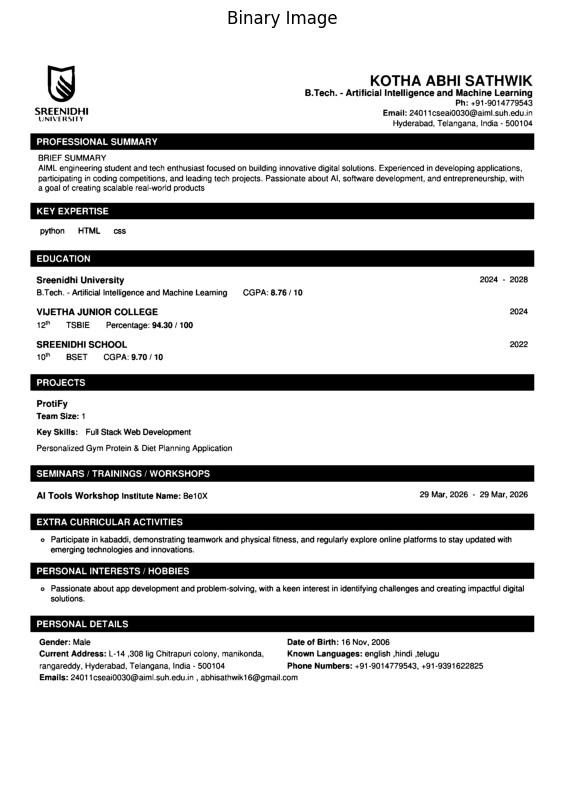

In [18]:
binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

plt.figure(figsize=(8,10))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

In [19]:
processed_path = "images/processed_resume.png"

cv2.imwrite(processed_path, binary)

print("Processed image saved successfully.")
print(processed_path)

Processed image saved successfully.
images/processed_resume.png


# ==========================================
# MODULE 4: OCR Text Extraction
# ==========================================

## Objective

Extract all text from the preprocessed resume image using Tesseract OCR.


In [45]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
import os

In [46]:
print("Tesseract Version:")
print(pytesseract.get_tesseract_version())

Tesseract Version:
5.5.0.20241111


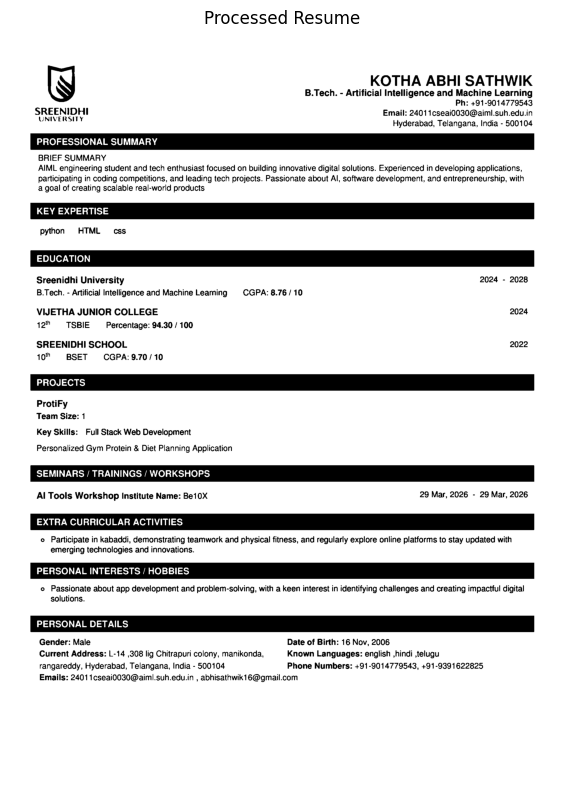

In [47]:
# Read processed image
processed_image = cv2.imread("images/processed_resume.png")

# Display image
plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.title("Processed Resume")
plt.axis("off")
plt.show()

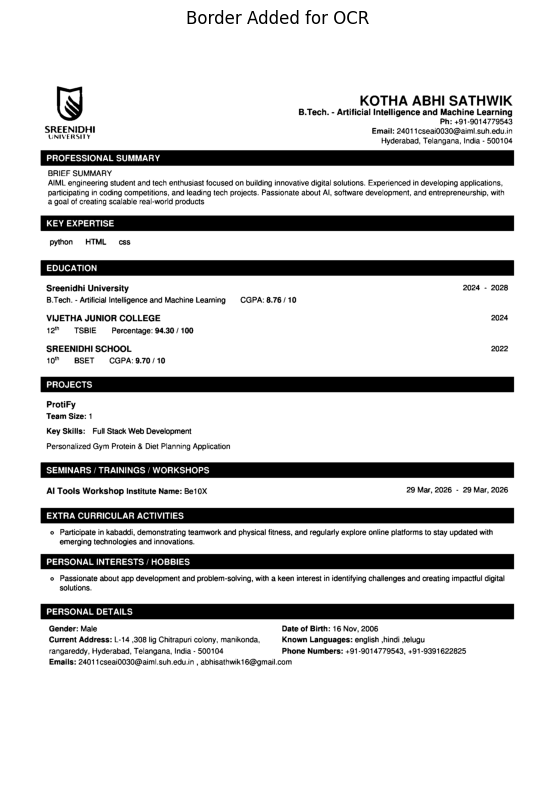

In [48]:
# Add white border around image

bordered_image = cv2.copyMakeBorder(
    processed_image,
    top=80,
    bottom=80,
    left=40,
    right=40,
    borderType=cv2.BORDER_CONSTANT,
    value=(255,255,255)
)

# Display bordered image
plt.figure(figsize=(8,10))
plt.imshow(cv2.cvtColor(bordered_image, cv2.COLOR_BGR2RGB))
plt.title("Border Added for OCR")
plt.axis("off")
plt.show()

In [50]:
# Convert image to RGB
rgb_image = cv2.cvtColor(bordered_image, cv2.COLOR_BGR2RGB)

# OCR Extraction
ocr_text = pytesseract.image_to_string(
    rgb_image,
    lang="eng",
    config="--oem 3 --psm 3"
)

print("=" * 60)
print("EXTRACTED OCR TEXT")
print("=" * 60)

print(ocr_text)

EXTRACTED OCR TEXT
KOTHA ABHI SATHWIK

B.Tech. - Artificial Intelligence and Machine Learning

Ph: +91-9014779543

SREENIDHI Email: 2401 1cseai0030@aiml.suh.edu.in
UNIVERSITY Hyderabad, Telangana, India - 500104

PROFESSIONAL SUMMARY

BRIEF SUMMARY
AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,

participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with
a goal of creating scalable real-world products

KEY EXPERTISE

python HTML css

EDUCATION

Sreenidhi University 2024 - 2028
B.Tech. - Artificial Intelligence and Machine Learning CGPA: 8.76 / 10

VIJETHA JUNIOR COLLEGE 2024
12"  TSBIE Percentage: 94.30 / 100

SREENIDHI SCHOOL 2022
10" BSET CGPA:9.70/10

PROJECTS

ProtiFy
Team Size: 1

Key Skills: Full Stack Web Development

Personalized Gym Protein & Diet Planning Application

SEMINARS / TRAININGS / WORKSHOPS

Al Tools Works

In [52]:
# Create output folder
os.makedirs("output", exist_ok=True)

output_file = "output/ocr_output.txt"

with open(output_file, "w", encoding="utf-8") as file:
    file.write(ocr_text)

print("\nOCR text saved successfully.")
print("Saved File :", output_file)


OCR text saved successfully.
Saved File : output/ocr_output.txt


In [54]:
with open("output/ocr_output.txt", "r", encoding="utf-8") as file:
    saved_text = file.read()

print("=" * 60)
print("OCR TEXT")
print("=" * 60)

print(saved_text)

OCR TEXT
KOTHA ABHI SATHWIK

B.Tech. - Artificial Intelligence and Machine Learning

Ph: +91-9014779543

SREENIDHI Email: 2401 1cseai0030@aiml.suh.edu.in
UNIVERSITY Hyderabad, Telangana, India - 500104

PROFESSIONAL SUMMARY

BRIEF SUMMARY
AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,

participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with
a goal of creating scalable real-world products

KEY EXPERTISE

python HTML css

EDUCATION

Sreenidhi University 2024 - 2028
B.Tech. - Artificial Intelligence and Machine Learning CGPA: 8.76 / 10

VIJETHA JUNIOR COLLEGE 2024
12"  TSBIE Percentage: 94.30 / 100

SREENIDHI SCHOOL 2022
10" BSET CGPA:9.70/10

PROJECTS

ProtiFy
Team Size: 1

Key Skills: Full Stack Web Development

Personalized Gym Protein & Diet Planning Application

SEMINARS / TRAININGS / WORKSHOPS

Al Tools Workshop Instit

In [56]:
print("=" * 50)
print("OCR Statistics")
print("=" * 50)

print("Characters :", len(saved_text))
print("Words      :", len(saved_text.split()))
print("Lines      :", len(saved_text.splitlines()))

OCR Statistics
Characters : 1734
Words      : 225
Lines      : 61


# MODULE 5 : RESUME INFORMATION EXTRACTION

In [58]:
import re

# Read OCR text
with open("output/ocr_output.txt", "r", encoding="utf-8") as file:
    text = file.read()

print(text[:600])

KOTHA ABHI SATHWIK

B.Tech. - Artificial Intelligence and Machine Learning

Ph: +91-9014779543

SREENIDHI Email: 2401 1cseai0030@aiml.suh.edu.in
UNIVERSITY Hyderabad, Telangana, India - 500104

PROFESSIONAL SUMMARY

BRIEF SUMMARY
AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,

participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with
a goal of creating scalable real-world products

KEY EXPERTISE

python HTML css

EDUCATION

Sreenid


In [66]:
# Split OCR text into lines
lines = [line.strip() for line in text.split("\n") if line.strip()]

candidate_name = ""

for line in lines:

    # Candidate name is usually the first line in uppercase
    if line.isupper():

        if "SUMMARY" not in line and "EDUCATION" not in line:

            candidate_name = line.title()
            break

print("Candidate Name :", candidate_name)

Candidate Name : Kotha Abhi Sathwik


In [68]:
# Fix OCR mistake where spaces are inserted inside email addresses
text = re.sub(
    r'(\d+)\s+([A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,})',
    r'\1\2',
    text
)

# Email extraction
email_pattern = r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}"

emails = re.findall(email_pattern, text)

# Remove duplicate emails
emails = list(dict.fromkeys(emails))

print("=" * 50)
print("EMAIL(S)")
print("=" * 50)

if emails:
    for email in emails:
        print(email)
else:
    print("No Email Found")

EMAIL(S)
24011cseai0030@aiml.suh.edu.in
abhisathwik16@gmail.com


In [69]:
phone_pattern = r"(?:\+91[- ]?)?[6-9]\d{9}"

phones = re.findall(phone_pattern, text)

# Remove duplicate phone numbers
phones = list(dict.fromkeys(phones))

print("=" * 50)
print("PHONE NUMBER(S)")
print("=" * 50)

if phones:
    for phone in phones:
        print(phone)
else:
    print("No Phone Number Found")

PHONE NUMBER(S)
+91-9014779543
+91-9391622825


In [70]:
skills_database = [

    "Python",
    "Java",
    "C",
    "C++",
    "HTML",
    "CSS",
    "JavaScript",
    "SQL",
    "Machine Learning",
    "Artificial Intelligence",
    "OpenCV",
    "React",
    "NodeJS",
    "Git",
    "Full Stack Web Development"

]

found_skills = []

for skill in skills_database:

    if re.search(r"\b" + re.escape(skill) + r"\b", text, re.IGNORECASE):

        found_skills.append(skill)

print("=" * 50)
print("SKILLS")
print("=" * 50)

for skill in found_skills:
    print(skill)

SKILLS
Python
HTML
CSS
Machine Learning
Artificial Intelligence
Full Stack Web Development


In [87]:
summary = []

start = lines.index("BRIEF SUMMARY") + 1
end = lines.index("KEY EXPERTISE")

summary = lines[start:end]

print("=" * 50)
print("PROFESSIONAL SUMMARY")
print("=" * 50)

for item in summary:
    print(item)

PROFESSIONAL SUMMARY
AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,
participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with
a goal of creating scalable real-world products


In [88]:
projects = []

start = lines.index("PROJECTS") + 1
end = lines.index("SEMINARS / TRAININGS / WORKSHOPS")

projects = lines[start:end]

print("=" * 50)
print("PROJECTS")
print("=" * 50)

for item in projects:
    print(item)

PROJECTS
ProtiFy
Team Size: 1
Key Skills: Full Stack Web Development
Personalized Gym Protein & Diet Planning Application


In [89]:
workshops = []

start = lines.index("SEMINARS / TRAININGS / WORKSHOPS") + 1
end = lines.index("EXTRA CURRICULAR ACTIVITIES")

workshops = lines[start:end]

print("=" * 50)
print("WORKSHOPS")
print("=" * 50)

for item in workshops:
    print(item)

WORKSHOPS
Al Tools Workshop Institute Name: Be10X 29 Mar, 2026 - 29 Mar, 2026


In [90]:
activities = []

start = lines.index("EXTRA CURRICULAR ACTIVITIES") + 1
end = lines.index("PERSONAL INTERESTS / HOBBIES")

activities = lines[start:end]

print("=" * 50)
print("EXTRA CURRICULAR ACTIVITIES")
print("=" * 50)

for item in activities:
    print(item)

EXTRA CURRICULAR ACTIVITIES
o Participate in kabaddi, demonstrating teamwork and physical fitness, and regularly explore online platforms to stay updated with
emerging technologies and innovations.


In [91]:
interests = []

start = lines.index("PERSONAL INTERESTS / HOBBIES") + 1
end = lines.index("PERSONAL DETAILS")

interests = lines[start:end]

print("=" * 50)
print("PERSONAL INTERESTS")
print("=" * 50)

for item in interests:
    print(item)

PERSONAL INTERESTS
o Passionate about app development and problem-solving, with a keen interest in identifying challenges and creating impactful digital
solutions.


In [94]:
candidate = {

    "Name": candidate_name,

    "Emails": emails,

    "Phone Numbers": phones,

    "Summary": summary,

    "Skills": found_skills,

    "Education": education,

    "Projects": projects,

    "Workshops": workshops,

    "Activities": activities,

    "Interests": interests

}

In [95]:
print("=" * 70)
print("          EXTRACTED RESUME INFORMATION")
print("=" * 70)

for key, value in candidate.items():

    print(f"\n{key}")
    print("-" * 40)

    if isinstance(value, list):

        if len(value) == 0:
            print("Not Available")

        else:
            for item in value:
                print(item)

    else:

        if value == "":
            print("Not Available")
        else:
            print(value)

print("\n" + "=" * 70)
print("Resume Information Extraction Completed Successfully")
print("=" * 70)

          EXTRACTED RESUME INFORMATION

Name
----------------------------------------
Kotha Abhi Sathwik

Emails
----------------------------------------
24011cseai0030@aiml.suh.edu.in
abhisathwik16@gmail.com

Phone Numbers
----------------------------------------
+91-9014779543
+91-9391622825

Summary
----------------------------------------
AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,
participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with
a goal of creating scalable real-world products

Skills
----------------------------------------
Python
HTML
CSS
Machine Learning
Artificial Intelligence
Full Stack Web Development

Education
----------------------------------------
Sreenidhi University 2024 - 2028
B.Tech. - Artificial Intelligence and Machine Learning CGPA: 8.76 / 10
VIJETHA JUNIOR COLLEGE 2024
12"  TSBIE Percentag

In [96]:
import json
import os

os.makedirs("output", exist_ok=True)

with open("output/candidate_information.json", "w", encoding="utf-8") as file:
    json.dump(candidate, file, indent=4)

print("Candidate information saved successfully.")

Candidate information saved successfully.


# MODULE 6: ATS SCORE CALCULATION

## Objective

Calculate an ATS score based on the information extracted from the resume.

The score is calculated using simple rule-based checks such as:
- Presence of Name
- Email
- Phone Number
- Skills
- Education
- Projects
  

In [97]:
ats_score = 0

In [98]:
# Name
if candidate["Name"]:
    ats_score += 10

# Email
if candidate["Emails"]:
    ats_score += 10

# Phone
if candidate["Phone Numbers"]:
    ats_score += 10

# Professional Summary
if candidate["Summary"]:
    ats_score += 10

# Skills
ats_score += min(len(candidate["Skills"]) * 5, 20)

# Education
if candidate["Education"]:
    ats_score += 10

# Projects
if candidate["Projects"]:
    ats_score += 15

# Workshops
if candidate["Workshops"]:
    ats_score += 5

# Activities
if candidate["Activities"]:
    ats_score += 5

# Interests
if candidate["Interests"]:
    ats_score += 5

candidate["ATS Score"] = ats_score

print("ATS Score :", ats_score, "/100")

ATS Score : 100 /100


In [99]:
if ats_score >= 90:
    rating = "Excellent"

elif ats_score >= 75:
    rating = "Very Good"

elif ats_score >= 60:
    rating = "Good"

elif ats_score >= 40:
    rating = "Average"

else:
    rating = "Needs Improvement"

print("Resume Rating :", rating)

Resume Rating : Excellent


In [100]:
print("=" * 60)
print("ATS SCORE REPORT")
print("=" * 60)

print("Candidate Name :", candidate["Name"])
print("ATS Score      :", ats_score, "/100")
print("Resume Rating  :", rating)

ATS SCORE REPORT
Candidate Name : Kotha Abhi Sathwik
ATS Score      : 100 /100
Resume Rating  : Excellent


In [101]:
print("\nSuggestions")

if len(candidate["Skills"]) < 5:
    print("- Add more technical skills.")

if not candidate["Projects"]:
    print("- Add more project details.")

if not candidate["Summary"]:
    print("- Add a professional summary.")

if not candidate["Workshops"]:
    print("- Mention workshops or certifications.")

if ats_score >= 90:
    print("- Excellent resume. Keep it updated.")


Suggestions
- Excellent resume. Keep it updated.


# MODULE 7 : RESUME IMPROVEMENT SUGGESTIONS

## Objective

Generate personalized suggestions to improve the resume based on the ATS evaluation.

The suggestions are generated using simple rule-based analysis.

In [104]:
suggestions = []

In [106]:
if len(candidate["Skills"]) < 5:
    suggestions.append("Add more technical skills.")

if len(candidate["Projects"]) < 2:
    suggestions.append("Include more academic or personal projects.")

if len(candidate["Summary"]) == 0:
    suggestions.append("Add a professional summary.")

if len(candidate["Workshops"]) == 0:
    suggestions.append("Mention workshops or certifications.")

if len(candidate["Activities"]) == 0:
    suggestions.append("Include extracurricular activities.")

if len(candidate["Interests"]) == 0:
    suggestions.append("Add your interests or hobbies.")

if ats_score >= 90:
    suggestions.append("Excellent resume. Continue updating it regularly.")

In [108]:
print("=" * 60)
print("RESUME IMPROVEMENT SUGGESTIONS")
print("=" * 60)

for i, suggestion in enumerate(suggestions, start=1):
    print(f"{i}. {suggestion}")
    

RESUME IMPROVEMENT SUGGESTIONS
1. Excellent resume. Continue updating it regularly.
2. Excellent resume. Continue updating it regularly.


In [110]:
candidate["Suggestions"] = suggestions

In [111]:
print("=" * 60)
print("FINAL ATS RESULT")
print("=" * 60)

print("Candidate Name :", candidate["Name"])
print("ATS Score      :", candidate["ATS Score"], "/100")
print("Resume Rating  :", rating)

print("\nSuggestions")

for suggestion in suggestions:
    print("-", suggestion)

FINAL ATS RESULT
Candidate Name : Kotha Abhi Sathwik
ATS Score      : 100 /100
Resume Rating  : Excellent

Suggestions
- Excellent resume. Continue updating it regularly.
- Excellent resume. Continue updating it regularly.


# MODULE 8 : SAVE ATS REPORT

## Objective

Generate and save the final ATS evaluation report.
    

In [114]:
import json
import os

candidate["Resume Rating"] = rating
candidate["Suggestions"] = suggestions

In [115]:
os.makedirs("output", exist_ok=True)

with open("output/final_ats_report.json", "w", encoding="utf-8") as file:

    json.dump(candidate, file, indent=4)

print("Final ATS Report Saved Successfully.")

Final ATS Report Saved Successfully.


In [116]:
with open("output/final_ats_report.json", "r", encoding="utf-8") as file:

    report = json.load(file)

print(json.dumps(report, indent=4))

{
    "Name": "Kotha Abhi Sathwik",
    "Emails": [
        "24011cseai0030@aiml.suh.edu.in",
        "abhisathwik16@gmail.com"
    ],
    "Phone Numbers": [
        "+91-9014779543",
        "+91-9391622825"
    ],
    "Summary": [
        "AIML engineering student and tech enthusiast focused on building innovative digital solutions. Experienced in developing applications,",
        "participating in coding competitions, and leading tech projects. Passionate about Al, software development, and entrepreneurship, with",
        "a goal of creating scalable real-world products"
    ],
    "Skills": [
        "Python",
        "HTML",
        "CSS",
        "Machine Learning",
        "Artificial Intelligence",
        "Full Stack Web Development"
    ],
    "Education": [
        "Sreenidhi University 2024 - 2028",
        "B.Tech. - Artificial Intelligence and Machine Learning CGPA: 8.76 / 10",
        "VIJETHA JUNIOR COLLEGE 2024",
        "12\"  TSBIE Percentage: 94.30 / 100",
       